----------------------------------------------------------------------------------------------------

# ***FastAPI - Autenticação e Autorização***

----------------------------------------------------------------------------------------------------

# ***1. Uso de tokens para autenticação*** 

## ***1.1 Criação do arquvo 'auth.py' nas seguintes pastas***

Criaremos um novo arquivo chamado 'auth.py' nas pastas 'controllers', 'models''schemas', 'services', 'views':.

A lógica é a mesma para o 'post.py' feito anteriormente.

### ***1.1.1. 'auth.py' na pasta 'controllers':***

In [ ]:
from fastapi import APIRouter

from schemas.auth import LoginIn
from core.security import sign_jwt
from views.auth import LoginOut

router = APIRouter(prefix= "/auth", tags= ["auth"])

@router.post("/login", response_model= LoginOut)
async def login(data: LoginIn):
    return sign_jwt(user_id= data.user_id)

### ***1.1.2. 'auth.py' na pasta 'schemas':***

In [ ]:
from pydantic import BaseModel

class LoginIn(BaseModel):
    user_id: int

### ***1.1.2. 'auth.py' na pasta 'schemas':***

In [ ]:
from pydantic import BaseModel

class LoginOut(BaseModel):
    access_token: str

### ***1.1.3. 'security.py' na pasta 'core':***

Esta pasta 'core' ainda não foi criada. Então, fora de qualquer pasta, a criaremos dentro do projeto, estando em conjunto das demais pastas:

Atenção: Será necessário utilizar o 'jwt', para isso será necessário instala-lo. No terminal, se o seu projeto estiver rodando, utilize Ctrl + C. O terminal permitirá dar novos comandos. E então, digite:

    poetry add pyjwt

E então para voltar com o projeto, digite no terminal:

    uvicorn app.main:app --reload

----------------------------------------------------------------------------------------------------

## ***1.2 Criação do endpoint Login - POST***

No FlashPost, criaremos uma nova pasta chamda 'Auth' e um novo endpoint nela chamado 'login', do tipo POST.

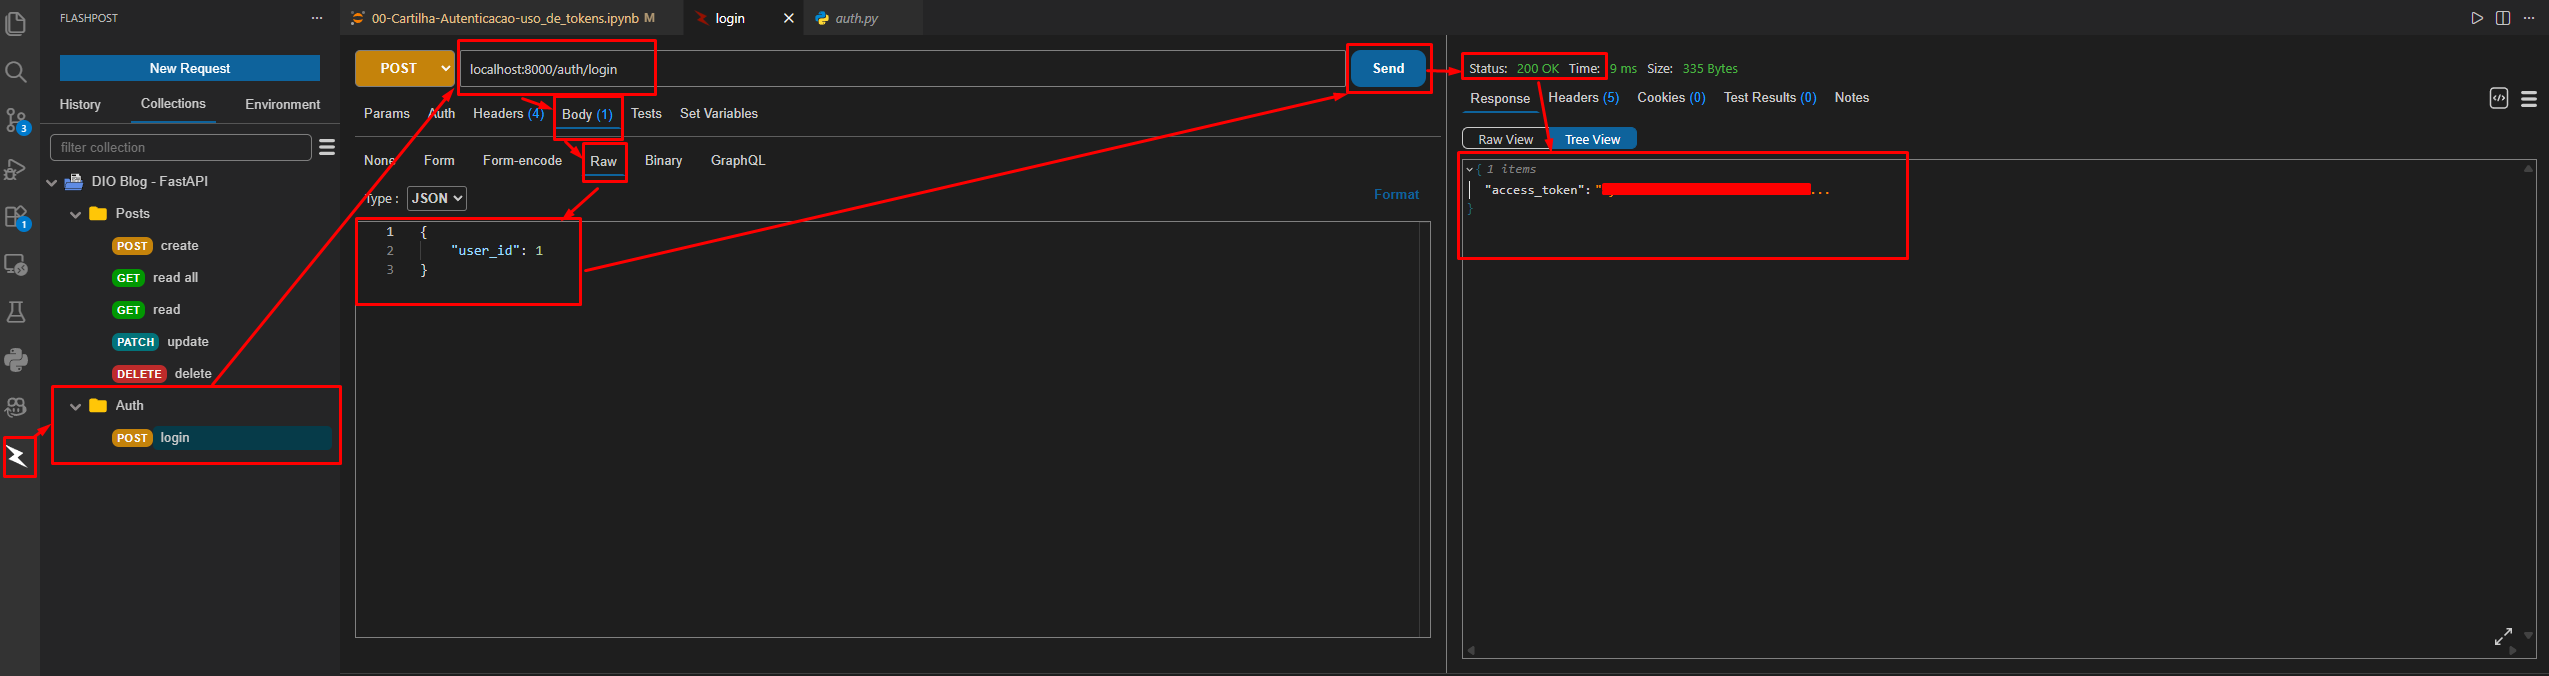

Obs.: É fundamental analizar se o endereço esta correto e se no body, em Raw, o json é exatamente como esta na imagem acima.

----------------------------------------------------------------------------------------------------

# ***2. Autenticação*** 

## ***2.1 Autorização - Confirma se há um token para acessar, caso o contrário não aceitará o acesso***

### ***2.1.1. 'post.py' na pasta 'controllers'***

Algumas atualizações necessárias no arquivo 'post.py':

Obs.: Todos os métodos serão autentidacados, por isso atualizaremos com o router para ter essa dependencia para acesso.

In [ ]:
import time
from typing import Annotated
from uuid import uuid4

import jwt
from fastapi import Depends, HTTPException, Request, status
from fastapi.security import HTTPBearer
from pydantic import BaseModel

SECRET = "minha-chave-super-secreta-32bytes!"
ALGORITHM = "HS256"

class AcessToken(BaseModel):
    iss: str
    sub: str
    aud: str
    exp: float
    iat: float
    nbf: float
    jti: str


class JWTToken(BaseModel):
    access_token: AcessToken


def sign_jwt(user_id: int) -> JWTToken:
    now = time.time()
    payload = {
        "iss": "curse-fastapi.com.br",
        "sub": str(user_id),
        "aud": "curso-fastapi",
        "exp": now + (60 * 30),
        "iat": now,
        "nbf": now,
        "jti": uuid4().hex,
    }

    token = jwt.encode(payload, SECRET, algorithm = ALGORITHM)
    return {"access_token": token}

async def decode_jwt(token: str) -> JWTToken | None:
    try:
        decoded_token = jwt.decode(token, SECRET, audience="curso-fastapi", algorithms=[ALGORITHM])
        _token = JWTToken.model_validate({"access_token": decoded_token})
        return _token if _token.access_token.exp >= time.time() else None
    except Exception as e:
        print(f"Erro no decode_jwt: {e}")
        return None
    

class JWTBearer(HTTPBearer):
    def __init__(self, auto_error: bool = True):
        super(JWTBearer, self).__init__(auto_error=auto_error)

    async def __call__(self, request: Request) -> JWTToken:
        credentials = await super().__call__(request)

        if credentials:
            if not credentials.scheme == "Bearer":
                raise HTTPException(
                    status_code=status.HTTP_401_UNAUTHORIZED,
                    detail="Invalid authentication scheme."
                )

            payload = await decode_jwt(credentials.credentials)
            if not payload:
                raise HTTPException(
                    status_code=status.HTTP_401_UNAUTHORIZED,
                    detail="Invalid or expired token."
                )
            return payload
        else:
            raise HTTPException(
                status_code=status.HTTP_401_UNAUTHORIZED,
                detail="Invalid authorization code."
            )
    

async def get_current_user(token: Annotated[JWTToken, Depends(JWTBearer())]) -> dict[str, int]:
    print(token)
    return {"user_id": int(token.access_token.sub)}


def login_required(current_user: Annotated[dict[str, int], Depends(get_current_user)]):
    if not current_user:
        raise HTTPException(status_code= status.HTTP_403_FORBIDDEN, detail= "Access denied")
    return current_user

## ***2.2. Acessando dados - Fastpost***

### ***2.1.1 Tentativa de usar o READ ALL***

Forçaremos um erro:

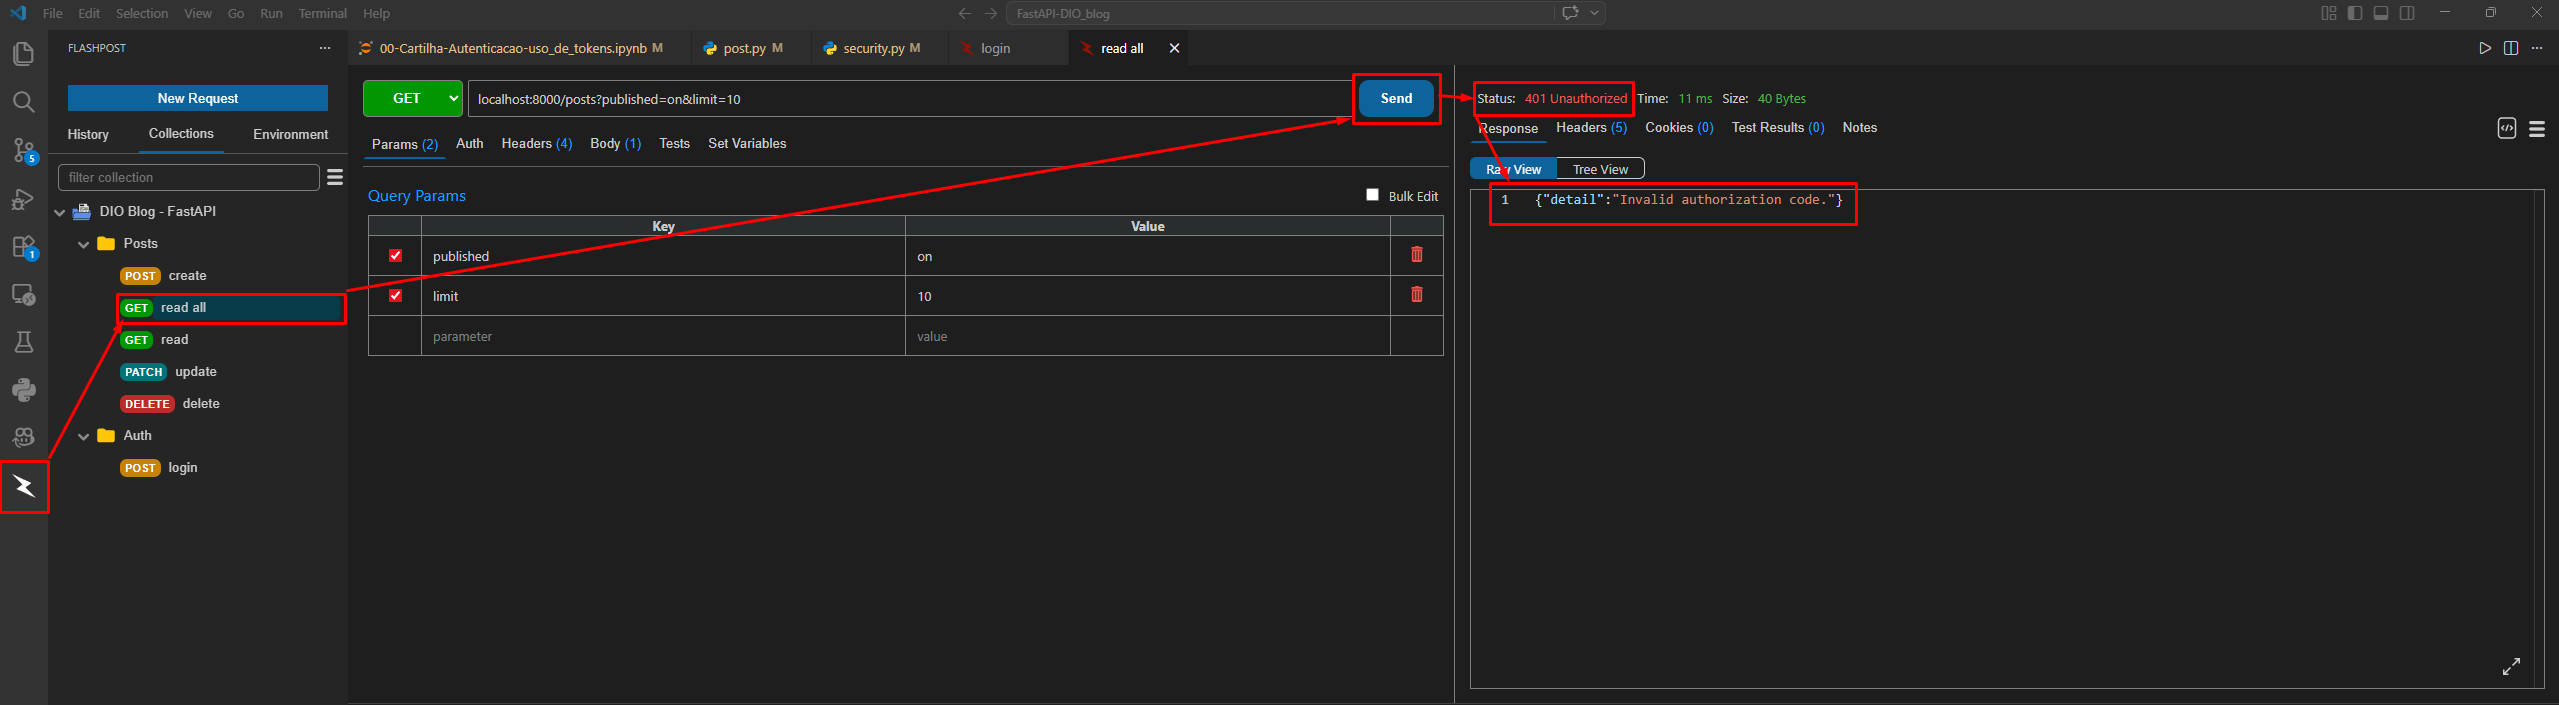

Esta correto. Nós adicionamos a camada de permissão via token. Em outras palavras, nossos dados estão salvos em segurança.

### ***2.1.2 Acessando os dados com o token que criamos anteriormente***

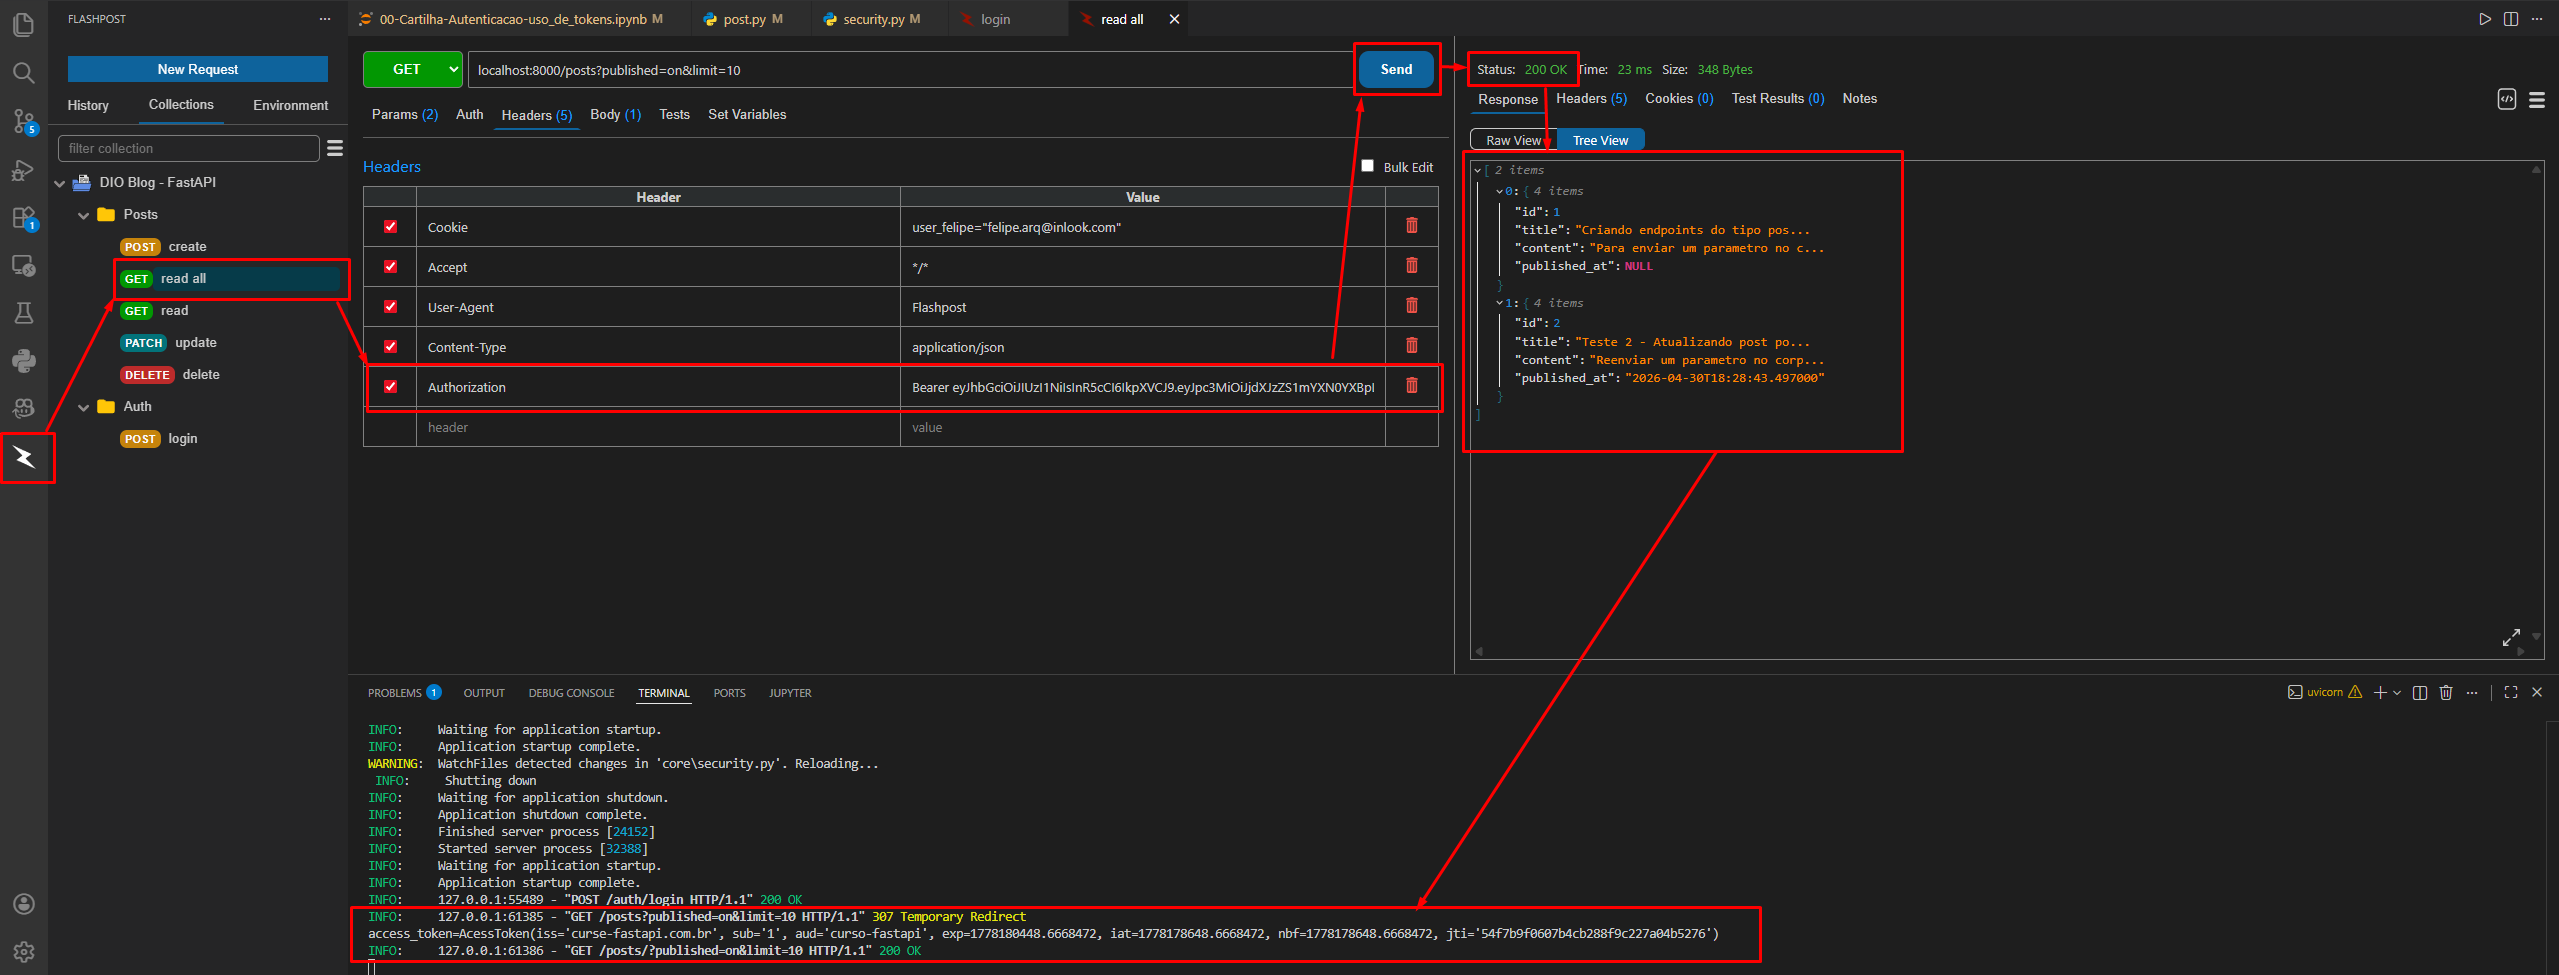

Obs.: 
- É importante lembrar que cada vez que você mudar o código de 'security', será necessário fazer um outro token, no Flaspost pela pasta 'Auth' com o seu endpoing 'login'.

- Na imagem acima, podemos ver que o 'read all' precisou de um novo parâmetro chamado 'Authorization' e, no campo ao lado, devemos colocar a palavra 'Bearer', que é o schema necessário. Sendo assim ficará da seguinte maneira:
    Bearer <novo_token_aqui>

## ***2.3. Fastpost - Realizando atualização de autenticação em cada endpoing***

### ***2.3.1. CREATE - Autenticação via token***

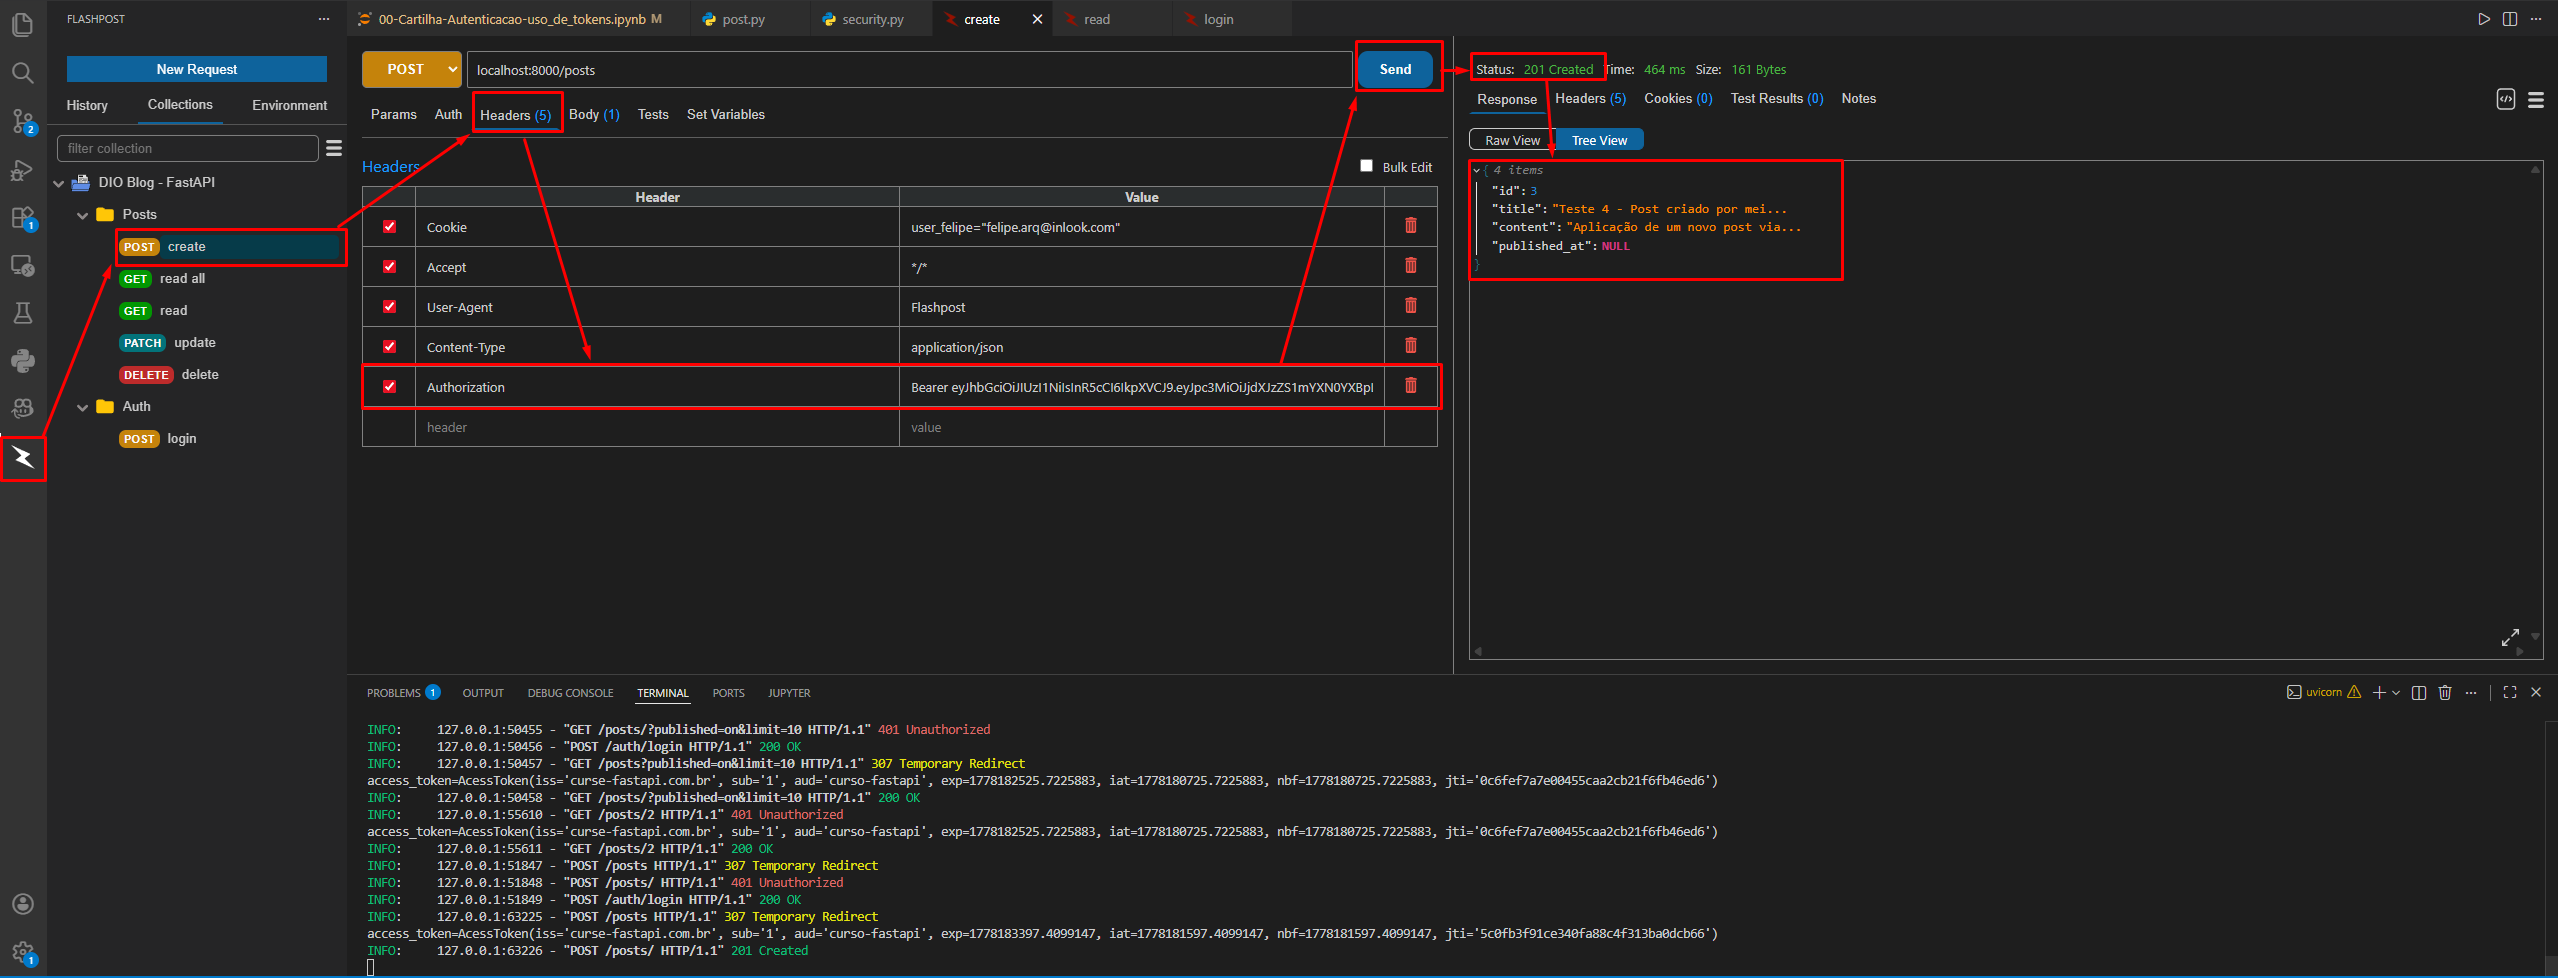

### ***2.3.1. READ ONE - Autenticação via token***

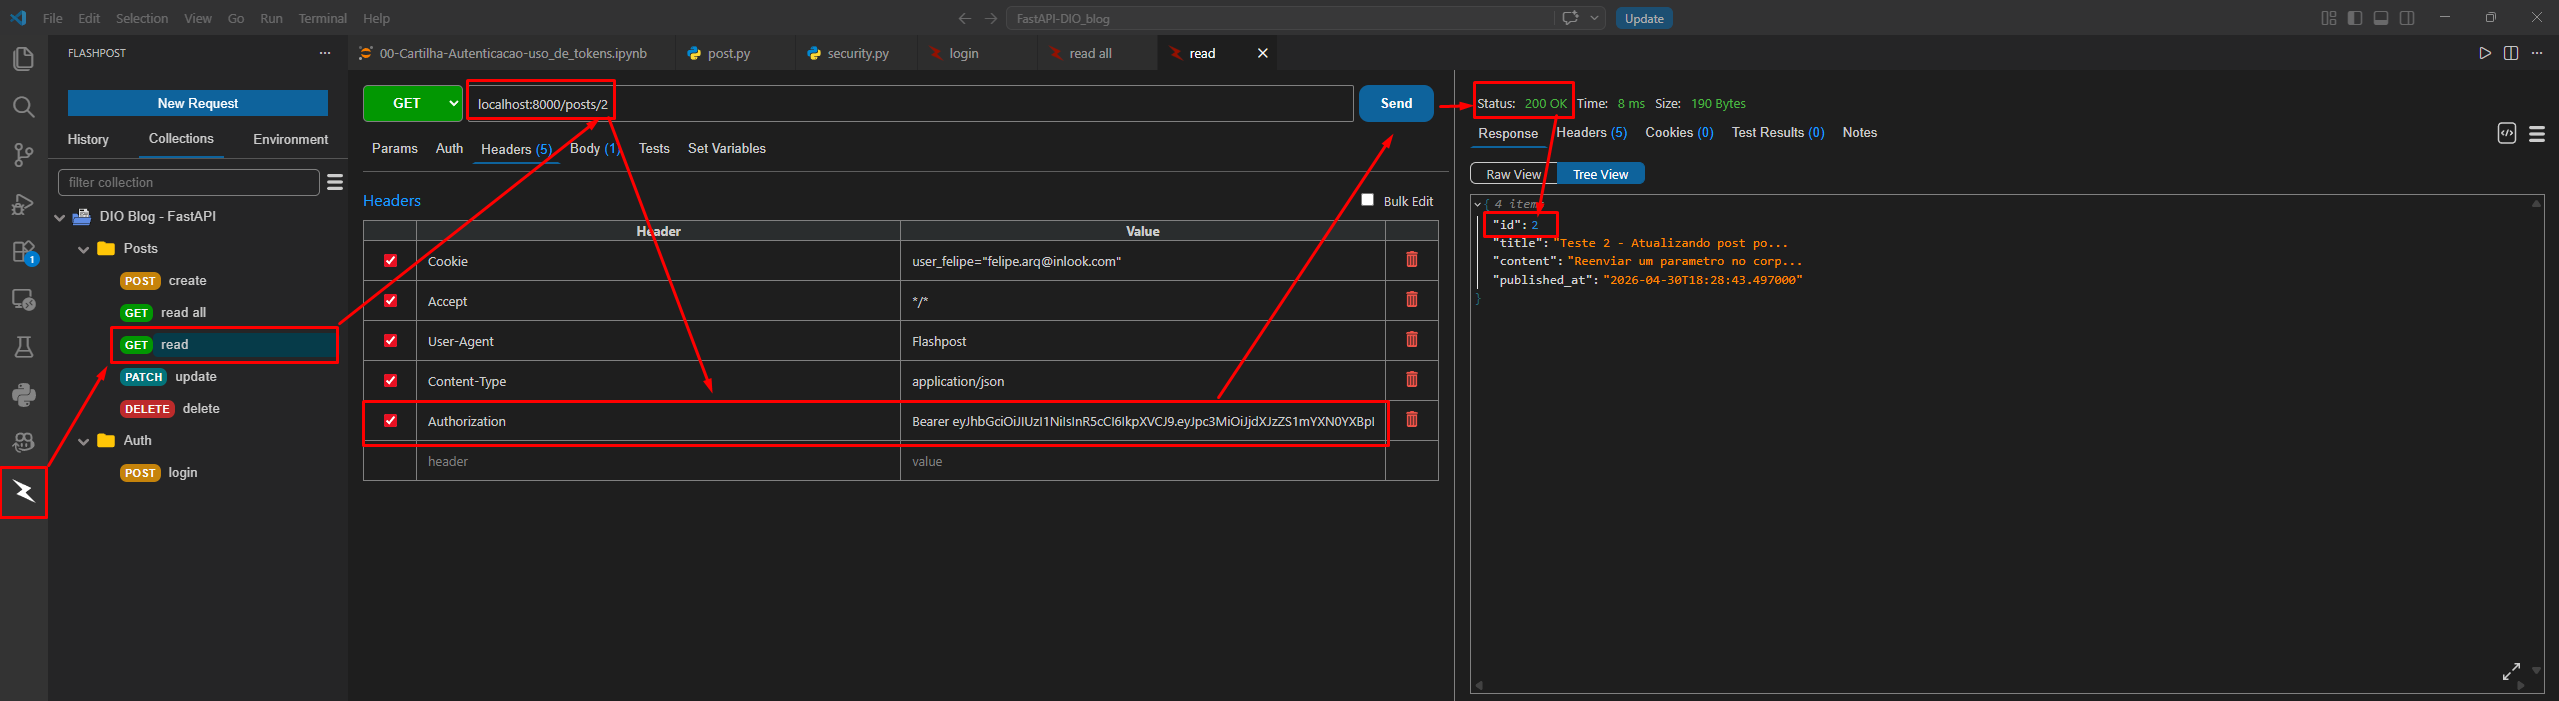